# Chapter 4a -- ESG product market overview, labels & regulation

Translated from `HSF/4. ESG Products/*.m` (Roncalli, *Handbook of
Sustainable Finance*): `chap4_esg_market2.m`, `esg_market4a.m`,
`esg_market4b.m`, `esg_market5.m`, `esg_market6a.m`, `esg_market6b.m`,
`chap4_label2.m`, `label3.m`, `label4.m`, and `chap4_regulation_sfdr1.m`
(10 scripts), plus the `Data/*.m` prep scripts feeding the real-data
sections.

Opens Chapter 4 (ESG Products) with the size and shape of the ESG fund
market: regional/firm-level assets under management, the largest
individual funds, how funds identifying as sustainable are labelled and
distributed geographically/sectorally, and the EU SFDR Article 8/9
regulatory split. Continued in `04b` (green/social/sustainability bond
issuance), `04c` (the greenium), and `04d` (real assets and impact
investing vehicles).

Five scripts read real fund/market data shipped in this repo's `Data/`
folder (Morningstar-style regional and firm-level ESG fund AUM, and a
top-40 climate-fund list) via `pandas.read_excel`. The rest reproduce
the book's illustrative bar charts and tables from their hardcoded
source values.

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

DATA_DIR = "../../data"


## 1. The global ESG fund market

Five scripts (`chap4_esg_market2/4a/4b/5/6a/6b.m`) sizing up the ESG
fund market: regional AUM and fund counts, the largest asset managers'
active/passive split in Europe vs. the US, market concentration, the
40 largest individual climate-themed funds, and each country's SFDR
Article 8/9 market share -- all read from real fund-industry data
shipped in `Data/`.

### 1.1 ESG fund AUM by region

From `chap4_esg_market4a.m`. Number of funds, fund count share, AUM
($bn), AUM share, and average fund size, by region -- read from the
`Global AUM` sheet of `chap4_esg_market3.xlsx`.

In [2]:

region = pd.read_excel(f"{DATA_DIR}/chap4_esg_market3.xlsx", sheet_name="Global AUM",
                        header=2, usecols="C:H")
region.columns = ["Region", "Funds (#)", "Funds (%)", "AUM ($bn)", "AUM (%)", "Fund size ($mn)"]
region = region.dropna(subset=["Region"]).reset_index(drop=True)
region["Funds (%)"] = 100 * region["Funds (%)"]
region["AUM (%)"] = 100 * region["AUM (%)"]
display(region.round(1))


,Region,Funds (#),Funds (%),AUM ($bn),AUM (%),Fund size ($mn)
0,Europe,5433,72.6,2492,84.0,458.7
1,United States,647,8.6,324,10.9,500.8
2,Asia ex-Japan,595,7.9,62,2.1,104.2
3,Australasia,263,3.5,33,1.1,125.5
4,Japan,235,3.1,25,0.8,106.4
5,Canada,312,4.2,31,1.0,99.4
6,Total,7485,100.0,2967,100.0,396.4


### 1.2 Largest asset managers, by region and active/passive split

From `chap4_esg_market4b.m`. Top-29 asset managers by global ESG AUM
($bn), split into active vs. passive management and by Europe/US
sub-totals -- read from the `AM` sheet of `chap4_esg_market3.xlsx`.

In [3]:

firms = pd.read_excel(f"{DATA_DIR}/chap4_esg_market3.xlsx", sheet_name="AM",
                       header=2, usecols="C:L")
firms.columns = ["Firm", "Global Total", "Global Active", "Global Passive",
                  "Europe Total", "Europe Active", "Europe Passive",
                  "US Total", "US Active", "US Passive"]
firms = firms.dropna(subset=["Firm"]).reset_index(drop=True)
display(firms.head(29).round(1))


,Firm,Global Total,Global Active,Global Passive,Europe Total,Europe Active,Europe Passive,US Total,US Active,US Passive
0,BlackRock,318.1,46.8,271.3,256.8,41.5,215.3,59.2,5.5,53.7
1,UBS,164.7,66.0,98.7,164.2,65.6,98.5,NaN,NaN,NaN
2,Amundi,161.0,84.1,76.9,164.0,76.3,87.7,8.5,8.5,NaN
3,DWS,93.1,56.0,37.2,89.7,57.4,32.2,5.2,4.9,0.3
4,BNP Paribas,85.8,54.4,31.4,85.8,54.4,31.4,NaN,NaN,NaN
5,Swisscanto,84.0,52.3,31.7,84.0,52.3,31.7,NaN,NaN,NaN
6,Natixis,74.5,72.0,2.5,73.8,71.3,2.5,NaN,NaN,NaN
7,Nordea,57.2,57.2,NaN,57.2,57.2,NaN,NaN,NaN,NaN
8,Pictet,49.7,49.7,NaN,49.7,49.7,NaN,NaN,NaN,NaN
9,Vanguard,47.2,2.8,44.4,NaN,NaN,13.1,30.5,1.4,29.0


### 1.3 Market concentration: top-20 asset managers, Europe vs. US

From `chap4_esg_market5.m`. Cumulative AUM share of the 20 largest
asset managers (overall/active/passive), as a percentage of each
region's total ESG AUM (from section 1.1: EUR 2,492bn, USD 324bn) --
same `firms` table as above.

Top-20 overall share: EU = 56.1%, US = 86.5%


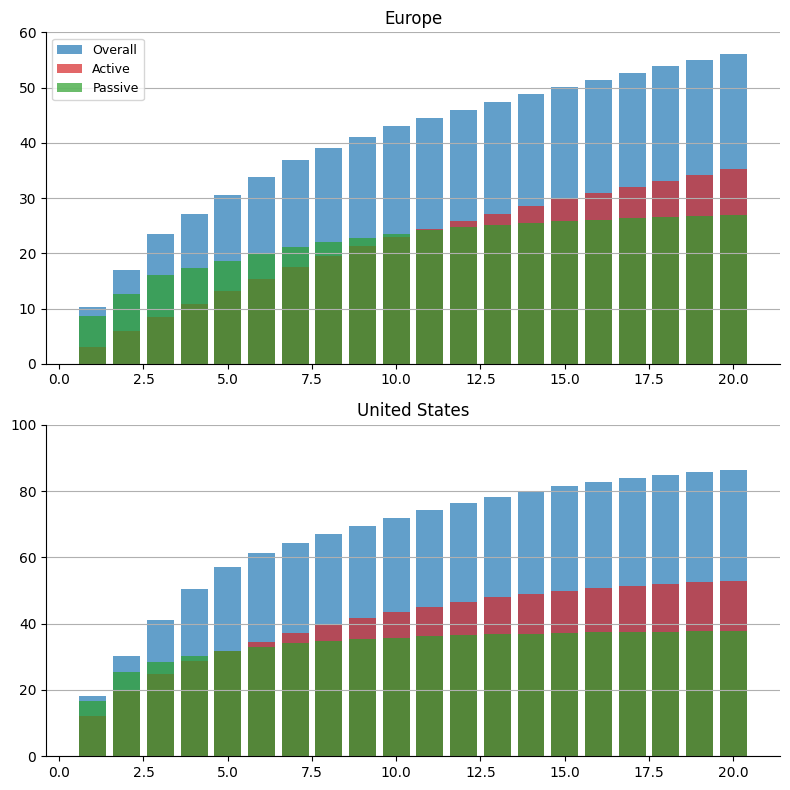

In [4]:

firm_data = firms.drop(columns="Firm").iloc[:-1]  # drop trailing subtotal row, matches source
eu_cols = ["Europe Total", "Europe Active", "Europe Passive"]
us_cols = ["US Total", "US Active", "US Passive"]

top20_eu = np.array([
    np.cumsum(np.sort(firm_data[c].dropna().values)[::-1][:20]) for c in eu_cols
]).T
top20_us = np.array([
    np.cumsum(np.sort(firm_data[c].dropna().values)[::-1][:20]) for c in us_cols
]).T

total_eu, total_us = 2492, 324
print(f"Top-20 overall share: EU = {100 * top20_eu[-1, 0] / total_eu:.1f}%, "
      f"US = {100 * top20_us[-1, 0] / total_us:.1f}%")

fig, axes = plt.subplots(2, 1, figsize=(8, 8))
x = np.arange(1, 21)
labels = ["Overall", "Active", "Passive"]
colors = ["tab:blue", "tab:red", "tab:green"]
for ax, data, total, title, ylim in [
    (axes[0], top20_eu, total_eu, "Europe", (0, 60)),
    (axes[1], top20_us, total_us, "United States", (0, 100)),
]:
    for j in range(3):
        ax.bar(x, 100 * data[:, j] / total, color=colors[j], label=labels[j], alpha=0.7)
    ax.set_title(title)
    ax.set_ylim(*ylim)
    ax.grid(axis="y")

axes[0].legend(fontsize=9)
plt.tight_layout()
plt.show()


### 1.4 The 40 largest climate-themed funds

From `chap4_esg_market6a.m`. The 40 largest funds by AUM ($bn) in a
"climate" investment category (Climate Transition, Climate Solutions,
Low Carbon, ...), across countries -- read from `chap4_esg_market4.xlsx`.

In [5]:

top_funds = pd.read_excel(f"{DATA_DIR}/chap4_esg_market4.xlsx", sheet_name="Feuil1",
                           header=None, usecols="C:F", skiprows=3, nrows=40)
top_funds.columns = ["Country", "Fund", "Category", "AUM ($bn)"]
display(top_funds.round(2))

print()
print("By category:")
display(top_funds.groupby("Category")["AUM ($bn)"].agg(["count", "sum"]).sort_values("sum", ascending=False))


,Country,Fund,Category,AUM ($bn)
0,Europe,ACS Climate Transition World Equity Fund,Climate Transition,12.80
1,Europe,iShares MSCI USA ESG Enhanced ETF,Climate Transition,12.20
2,Europe,Nordea 1 Global Climate and Environment Fund,Climate Solutions,10.80
3,Europe,Blackrock ACS World ESG Equity Tracker Fund,Low Carbon,10.20
4,Europe,Pictet Global Environmental Opportunities,Climate Solutions,8.40
5,Europe,Handelsbanken Global Index Criteria,Climate Transition,8.00
6,Europe,iShares Environment & Low Carbon Tilt Real Est...,Low Carbon,7.90
7,Europe,Blackrock ACS World Low Carbon Equity Tracker ...,Low Carbon,7.50
8,Europe,BlackRock Sustainable Energy Fund,Clean Technology,7.30
9,Europe,Amundi MSCI USA SRI PAB,Climate Transition,6.30



By category:


,count,sum
Category,,
Climate Transition,10,48.038
Climate Solutions,10,31.078
Low Carbon,9,28.666
Clean Technology,11,26.140


### 1.5 Concentration among the largest managers

From `chap4_esg_market6b.m`. Of the top-40 climate funds above (total
AUM $534bn), the 16 largest single funds already account for a
specific share -- reproduced from the book's own hardcoded per-fund
AUM figures ($bn), which is a finer breakdown than the top_funds table
above provides row-by-row.

In [6]:

total_aum = 534
fund_aum = np.array([447, 45.142, 31.7, 2.775, 2.615, 1.680, 1.510, 1.185,
                      0.104, 0.098, 0.083, 0.070, 0.018, 0.009, 0.009, 0.002])
print(f"Total: {total_aum}, sum of listed funds: {fund_aum.sum():.1f}")
share = fund_aum / total_aum
print("Share of total AUM (%):", np.round(100 * share, 1))


Total: 534, sum of listed funds: 534.0
Share of total AUM (%): [83.7  8.5  5.9  0.5  0.5  0.3  0.3  0.2  0.   0.   0.   0.   0.   0.
  0.   0. ]


### 1.6 SFDR Article 8/9 market share, by country

From `chap4_esg_market2.m`. For each EU country, the share of the
domestic fund market classified Article 8 vs. Article 9 under SFDR, in
EUR billions and as a percentage of that country's total fund market
-- read from the `Country (2)` sheet of `chap4_esg_market1.xlsx`.

One row's country name reads as just `"s"` in the source spreadsheet
itself (between Italy and Luxembourg, likely a merged-cell artifact
upstream) -- left as-is rather than guessed at, per this project's
no-fabrication policy for source data.

In [7]:

sfdr_country = pd.read_excel(f"{DATA_DIR}/chap4_esg_market1.xlsx", sheet_name="Country (2)",
                              header=2, usecols="B:J")
sfdr_country.columns = ["Country", "Article 8 (%)", "Article 9 (%)", "Article 8 (EUR bn)",
                         "Article 8 mkt (%)", "Article 9 (EUR bn)", "Article 9 mkt (%)",
                         "Art9/Art8 ratio", "Country mkt share (%)"]
sfdr_country = sfdr_country.dropna(subset=["Country"]).reset_index(drop=True)
for col in ["Article 8 (%)", "Article 9 (%)", "Article 8 mkt (%)", "Article 9 mkt (%)",
            "Art9/Art8 ratio", "Country mkt share (%)"]:
    sfdr_country[col] = 100 * sfdr_country[col]
display(sfdr_country.round(2))


,Country,Article 8 (%),Article 9 (%),Article 8 (EUR bn),Article 8 mkt (%),Article 9 (EUR bn),Article 9 mkt (%),Art9/Art8 ratio,Country mkt share (%)
0,Austria,NaN,2.5,77.0,1.20,5.00,1.46,6.49,1.21
1,Belgium,65.6,5.2,120.0,1.86,9.60,2.81,8.00,1.11
2,Croatia,36.9,0.3,1.0,0.02,0.00,0.00,0.00,0.02
3,Denmark,40.3,2.5,114.0,1.77,7.10,2.08,6.23,1.71
4,Finland,87.0,10.4,120.0,1.86,14.40,4.22,12.00,0.84
5,France,50.3,3.4,903.0,14.03,61.30,17.95,6.79,12.71
6,Germany,15.8,0.2,410.0,6.37,5.00,1.46,1.22,15.71
7,Greece,3.9,NaN,0.5,0.01,0.00,0.00,0.00,0.08
8,Hungary,2.3,NaN,0.5,0.01,0.02,0.01,4.00,0.14
9,Ireland,36.1,0.9,1015.0,15.77,24.40,7.14,2.40,22.15


## 2. GSS-labelled instruments: geography, sector, and count

Three scripts (`chap4_label2/3/4.m`) looking at how "labelled" (green/
social/sustainability) instruments break down -- by an unlabelled
four-way split, by region over time, and by issuer sector. All three
are illustrative reproductions of the book's own hardcoded source
values (no external data file).

### 2.1 A four-way breakdown

From `chap4_label2.m`. The source code carries four raw counts with no
category names attached in the script itself (the labels would have
been in the book's own figure caption, not in the `.m` source) -- shown
here as given.

In [8]:

counts = np.array([1276, 1544, 1116, 301])
total = counts.sum()
print("Total:", total)
print("Share (%):", np.round(100 * counts / total, 2))


Total: 4237
Share (%): [30.12 36.44 26.34  7.1 ]


### 2.2 Labelled-instrument issuance by region, 2018-2022

From `chap4_label3.m`. Annual issuance (count or $bn, units not
specified in source) of green/social/sustainability-labelled
instruments by region, 2018-2022, sorted by 2022 issuance.

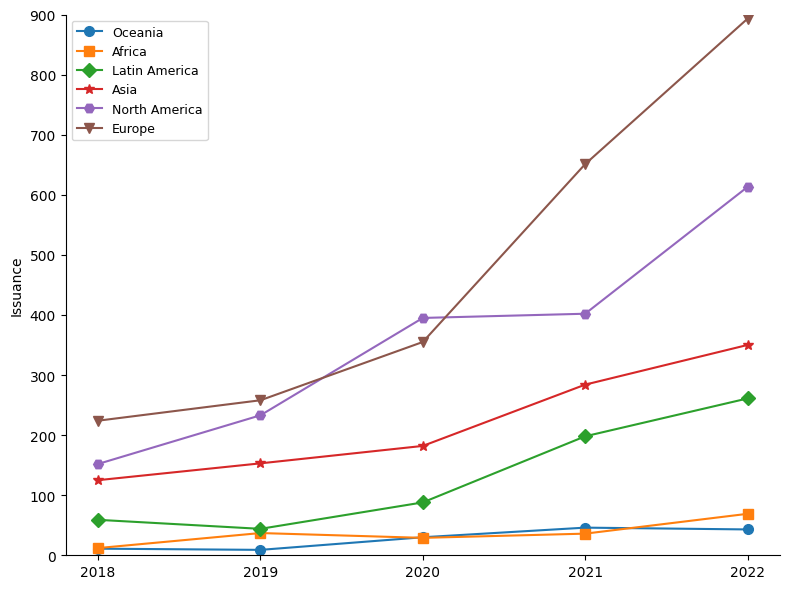

In [9]:

data = np.array([
    [224, 258, 355, 651, 893],
    [152, 233, 395, 402, 613],
    [125, 153, 182, 284, 350],
    [12, 37, 29, 36, 69],
    [11, 9, 30, 46, 43],
    [59, 44, 88, 198, 261],
])
regions = ["Europe", "North America", "Asia", "Africa", "Oceania", "Latin America"]
years = np.arange(2018, 2023)

order = np.argsort(data[:, -1])
data, regions = data[order], [regions[i] for i in order]

fig, ax = plt.subplots(figsize=(8, 6))
markers = ["o", "s", "D", "*", "H", "v"]
colors = plt.cm.tab10.colors
for i in range(len(regions)):
    ax.plot(years, data[i], marker=markers[i % len(markers)], color=colors[i % len(colors)],
            linewidth=1.5, markersize=7, label=regions[i])

ax.set_xticks(years)
ax.set_ylim(0, 900)
ax.legend(fontsize=9, loc="upper left")
ax.set_ylabel("Issuance")
plt.tight_layout()
plt.show()


### 2.3 Labelled-instrument issuance by sector

From `chap4_label4.m`. Sector breakdown of labelled-instrument
issuers, showing each sector's share of 2019-2023 cumulative issuance
and its share of 2023 issuance alone.

In [10]:

sector_data = np.array([
    [29, 42, 85, 139, 160, 120],
    [19, 20, 28, 64, 71, 62],
    [13, 18, 28, 61, 109, 96],
    [4, 8, 12, 36, 27, 24],
    [7, 17, 20, 55, 62, 51],
    [8, 8, 20, 46, 60, 59],
    [4, 14, 19, 43, 55, 42],
    [2, 7, 17, 21, 47, 60],
    [11, 18, 36, 69, 104, 107],
])
sectors = ["Oil & Gas", "Utilities", "Banking and Financial Services", "Mining",
           "Food and Beverage", "Industrials and Construction",
           "Retail, Personal, and Household Goods", "Travel and Airlines", "Other"]

total_1923 = sector_data[:, :5].sum(axis=1)
p_total = 100 * total_1923 / total_1923.sum()
p_2023 = 100 * sector_data[:, 5] / sector_data[:, 5].sum()

table = pd.DataFrame({"Sector": sectors, "2019-2023 share (%)": p_total, "2023 share (%)": p_2023})
display(table.round(1))


,Sector,2019-2023 share (%),2023 share (%)
0,Oil & Gas,26.1,19.3
1,Utilities,11.6,10.0
2,Banking and Financial Services,13.1,15.5
3,Mining,5.0,3.9
4,Food and Beverage,9.2,8.2
5,Industrials and Construction,8.1,9.5
6,"Retail, Personal, and Household Goods",7.7,6.8
7,Travel and Airlines,5.4,9.7
8,Other,13.7,17.2


## 3. Regulation: SFDR fund classification

From `chap4_regulation_sfdr1.m`. The distribution of EU SFDR Article 8
("light green", promoting environmental/social characteristics) and
Article 9 ("dark green", sustainable investment objective) funds by
some size or score decile (0-100, units not specified in source).

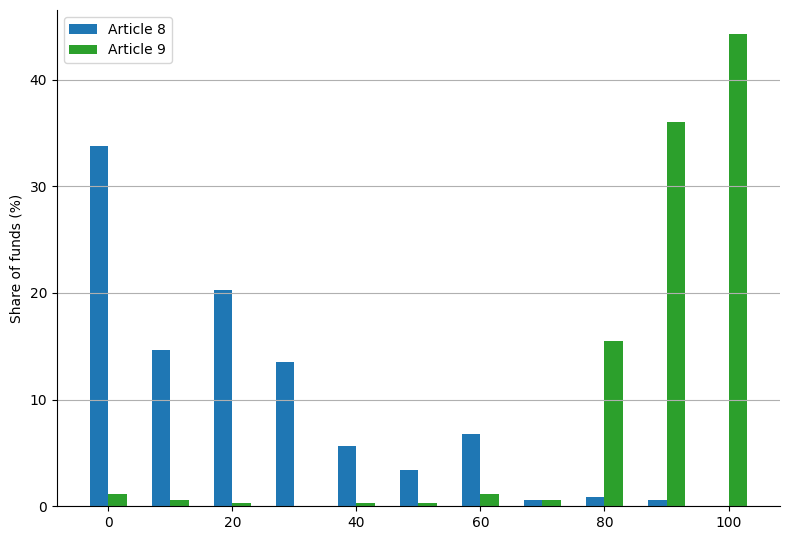

In [11]:

label = np.arange(0, 101, 10)
data_art8 = np.array([30, 13, 18, 12, 5, 3, 6, 0.5, 0.75, 0.5, 0])
data_art9 = np.array([1, 0.5, 0.25, 0, 0.25, 0.25, 1, 0.5, 14, 32.5, 40])
data_art8 = 100 * data_art8 / data_art8.sum()
data_art9 = 100 * data_art9 / data_art9.sum()

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.bar(label - 1.5, data_art8, width=3, color="tab:blue", label="Article 8")
ax.bar(label + 1.5, data_art9, width=3, color="tab:green", label="Article 9")
ax.set_ylabel("Share of funds (%)")
ax.legend()
ax.grid(axis="y")
plt.tight_layout()
plt.show()
